Loaded: airFoil2D_SST_31.283_-4.156_0.919_6.98_14.32.pts


C:\Users\romai\AppData\Local\Temp\ipykernel_63840\3262449342.py:45: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x, y, s=3, c=(0.3, 0.7, 1.0))


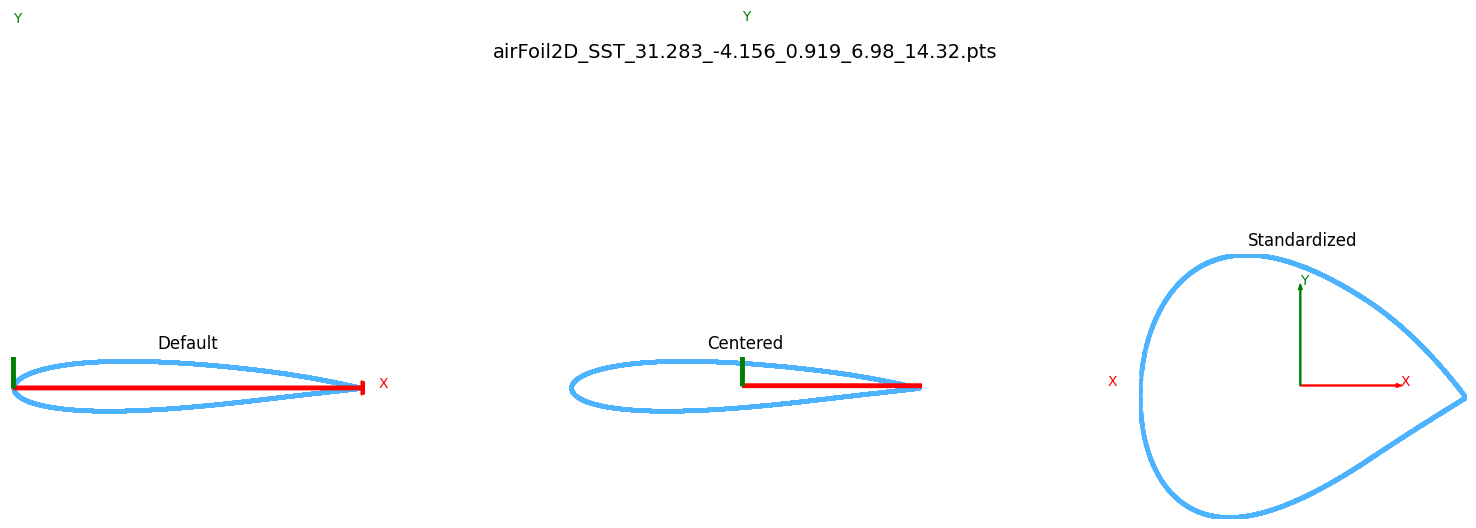

In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt

folders = {
    "Default": "./shapenet_like_out3/00000000/points",
    "Centered": "./shapenet_like_out3/11111111/points",
    "Standardized": "./shapenet_like_out3/22222222/points",
}

# load same filename from each folder
files = os.listdir(list(folders.values())[0])
files = [f for f in files if f.endswith(".pts")]
filename = files[0]

clouds = {}

for label, folder in folders.items():
    data = np.loadtxt(os.path.join(folder, filename))
    clouds[label] = data[:, :2]   # x,y only

print("Loaded:", filename)

# ------------------------------------------------
# compute global bounds so all plots share scale
# ------------------------------------------------
all_xy = np.vstack(list(clouds.values()))
xmin, xmax = all_xy[:,0].min(), all_xy[:,0].max()
ymin, ymax = all_xy[:,1].min(), all_xy[:,1].max()

dx = xmax - xmin
dy = ymax - ymin
pad = 0.1

xlim = (xmin - pad*dx, xmax + pad*dx)
ylim = (ymin - pad*dy, ymax + pad*dy)

# ------------------------------------------------
# plot
# ------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (label, xy) in zip(axes, clouds.items()):
    x, y = xy[:,0], xy[:,1]
    ax.scatter(x, y, s=3, c=(0.3, 0.7, 1.0))

    ax.set_title(label)
    ax.set_aspect("equal")
    # ax.set_xlim(*xlim)
    # ax.set_ylim(*ylim)*
    xmin, xmax = x.min(), x.max()
    ymin, ymax = y.min(), y.max()
    dx = 0.1
    dy = 0.1
    pad = 0.1

    ax.set_xlim(xmin - pad*dx, xmax + pad*dx)
    ax.set_ylim(ymin - pad*dy, ymax + pad*dy)
    ax.axis("off")

    # draw thick 2D axes
    L = 1
    w = L * 0.01

    ax.arrow(0, 0, L, 0,
             width=w, head_width=w*4, head_length=w*6,
             fc="r", ec="r")

    ax.arrow(0, 0, 0, L,
             width=w, head_width=w*4, head_length=w*6,
             fc="g", ec="g")

    ax.text(L*1.05, 0, "X", color="red", fontsize=10)
    ax.text(0, L*1.05, "Y", color="green", fontsize=10)

plt.suptitle(filename, fontsize=14)
plt.tight_layout()
plt.show()


Loaded: airFoil2D_SST_31.283_-4.156_0.919_6.98_14.32.pts


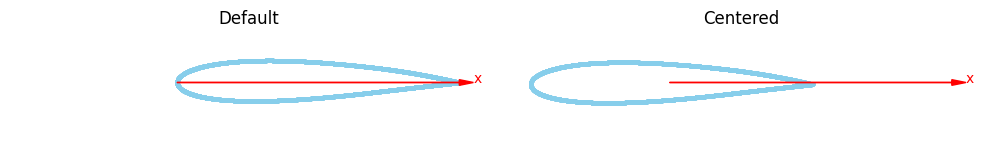

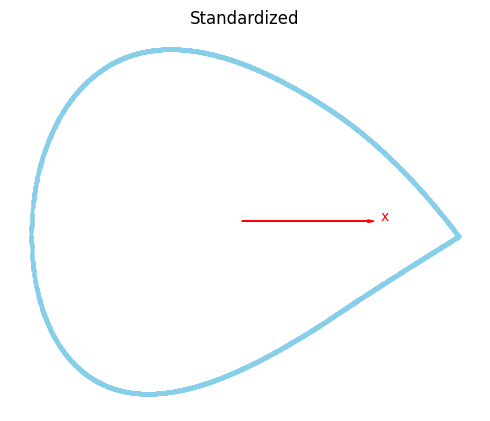

In [40]:
import numpy as np
import os
import matplotlib.pyplot as plt

base = "./shapenet_like_out3"
folders = {
    "Default": f"{base}/00000000/points",
    "Centered": f"{base}/11111111/points",
    "Standardized": f"{base}/22222222/points",
}

filename = [f for f in os.listdir(folders["Default"]) if f.endswith(".pts")][0]
print("Loaded:", filename)

clouds = {k: np.loadtxt(os.path.join(v, filename))[:, :2] for k, v in folders.items()}

# -----------------------------
# Figure 1: Default + Centered
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

xy = np.vstack([clouds["Default"], clouds["Centered"]])
xmin, xmax = xy[:,0].min(), xy[:,0].max()
ymin, ymax = xy[:,1].min(), xy[:,1].max()
pad = 0.1

for ax, label in zip(axes, ["Default", "Centered"]):
    x, y = clouds[label].T
    ax.scatter(x, y, s=3, c="skyblue")
    ax.set_title(label)
    ax.set_aspect("equal")
    ax.set_xlim(xmin - pad, xmax + pad)
    ax.set_ylim(ymin - pad, ymax + pad)
    ax.axis("off")

    # unit X axis
    ax.arrow(0, 0, 1, 0, head_width=0.02, head_length=0.05, fc="r", ec="r")
    ax.text(1.05, 0, "x", color="red")

plt.tight_layout()
plt.show()

# -----------------------------
# Figure 2: Standardized
# -----------------------------
fig, ax = plt.subplots(figsize=(5, 5))
x, y = clouds["Standardized"].T
ax.scatter(x, y, s=3, c="skyblue")
ax.set_title("Standardized")
ax.set_aspect("equal")
ax.axis("off")

# unit X axis
ax.arrow(0, 0, 1, 0, head_width=0.02, head_length=0.05, fc="r", ec="r")
ax.text(1.1, 0, "x", color="red")

plt.tight_layout()
plt.show()


Loaded: airFoil2D_SST_31.283_-4.156_0.919_6.98_14.32.pts


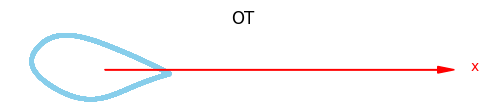

In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt

base = "./shapenet_like_out3"
folders = {
    "Default": f"{base}/00000000/points",
    "OT": f"{base}/40404040/points",
}

filename = [f for f in os.listdir(folders["Default"]) if f.endswith(".pts")][0]
print("Loaded:", filename)

clouds = {k: np.loadtxt(os.path.join(v, filename))[:, :2] for k, v in folders.items()}

fig, ax = plt.subplots(figsize=(5, 5))
x, y = clouds["OT"].T
ax.scatter(x, y, s=3, c="skyblue")
ax.set_title("OT")
ax.set_aspect("equal")
ax.axis("off")

# unit X axis
ax.arrow(0, 0, 1, 0, head_width=0.02, head_length=0.05, fc="r", ec="r")
ax.text(1.1, 0, "x", color="red")

plt.tight_layout()
plt.show()


In [2]:
import numpy as np
import open3d as o3d
import os
import random

folder = "./shapenet_like_out3/90909090/points"
# folder = "./shapenetcore_partanno_segmentation_benchmark_v0/02691156/points"
pts_files = [f for f in os.listdir(folder) if f.endswith(".pts")]
# random_file = random.choice(pts_files)
random_file = pts_files[20]
filepath = os.path.join(folder, random_file)

print("Loaded file:", random_file)

# Load point cloud
data = np.loadtxt(filepath)
x, y, z = data[:, 0], data[:, 1], data[:, 2]
points = np.vstack((x, y, z)).T
print(len(x))
# Create Open3D point cloud
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)

# Optional: set point color
pcd.paint_uniform_color([0.3, 0.7, 1.0])   # light blue

# Launch interactive viewer
o3d.visualization.draw_geometries([pcd],
    window_name=random_file,
    point_show_normal=False,
    width=900,
    height=700,
    mesh_show_wireframe=False
)



Loaded file: airFoil2D_SST_32.706_8.859_2.638_5.49_0.0_18.856.pts
512


In [ ]:
import numpy as np
import open3d as o3d
import os
import random

folder = "./"
pts_files = [f for f in os.listdir(folder) if f.endswith(".pts")]
# random_file = random.choice(pts_files)
random_file = pts_files[0]
filepath = os.path.join(folder, random_file)

print("Loaded file:", random_file)

# Load point cloud
data = np.loadtxt(filepath)
x, y, z = data[:, 0], data[:, 1], data[:, 2]
points = np.vstack((x, y, z)).T
print(len(x))
# Create Open3D point cloud
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)

# Optional: set point color
pcd.paint_uniform_color([0.3, 0.7, 1.0])   # light blue

# Launch interactive viewer
o3d.visualization.draw_geometries([pcd],
    window_name=random_file,
    point_show_normal=False,
    width=900,
    height=700,
    mesh_show_wireframe=False
)



Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


IndexError: list index out of range

In [1]:
import numpy as np
import open3d as o3d
import os
import random

folder = "./shapenet_like_out3/70707070/points"
# folder = "./shapenetcore_partanno_segmentation_benchmark_v0/02691156/points"
pts_files = [f for f in os.listdir(folder) if f.endswith(".pts")]
# random_file = random.choice(pts_files)
random_file = pts_files[0]
filepath = os.path.join(folder, random_file)

print("Loaded file:", random_file)

# Load point cloud
data = np.loadtxt(filepath)
x, y, z = data[:, 0], data[:, 1], data[:, 2]
points = np.vstack((x, y, z)).T
print(len(x))
# Create Open3D point cloud
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)

# Optional: set point color
pcd.paint_uniform_color([0.3, 0.7, 1.0])   # light blue




axis = o3d.geometry.TriangleMesh.create_coordinate_frame(
    size=1,     # length of the axes
    origin=[0, 0, 0]
)

o3d.visualization.draw_geometries(
    [pcd, axis],
    window_name=random_file,
    point_show_normal=False,
    width=900,
    height=700,
    mesh_show_wireframe=False
)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Loaded file: airFoil2D_SST_31.283_-4.156_0.919_6.98_14.32.pts
3000


In [2]:
import numpy as np
import open3d as o3d
import os

# ================================
# Load point cloud
# ================================

folder = "./shapenet_like_out3/80808080/points"
pts_files = [f for f in os.listdir(folder) if f.endswith(".pts")]

file = pts_files[0]
path = os.path.join(folder, file)

print("Loaded:", file)

data = np.loadtxt(path)
points = data[:, :3]

pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)
pcd.paint_uniform_color([0.3, 0.7, 1.0])

# Coordinate axis
# axis = o3d.geometry.TriangleMesh.create_coordinate_frame(size=1.0)

# ================================
# Animation + capture
# ================================

os.makedirs("frames", exist_ok=True)

import numpy as np

TOTAL_FRAMES = 120
RADIUS = 2.5

center = pcd.get_center()

def rotate_and_capture(vis):
    i = rotate_and_capture.i

    if i >= TOTAL_FRAMES:
        vis.close()
        return False

    theta = 2 * np.pi * i / TOTAL_FRAMES   # 0 → 2π

    cam_x = center[0] + RADIUS * np.cos(theta)
    cam_y = center[1] - 0.5
    cam_z = center[2] + RADIUS * np.sin(theta)

    ctr = vis.get_view_control()
    ctr.set_lookat(center)
    ctr.set_front([center[0] - cam_x, center[1] - cam_y, center[2] - cam_z])
    ctr.set_up([0, 1, 0])
    ctr.set_zoom(0.7)

    vis.capture_screen_image(f"frames/frame_{i:04d}.png")

    rotate_and_capture.i += 1
    return False

rotate_and_capture.i = 0


# ================================
# Viewer
# ================================

vis = o3d.visualization.Visualizer()
vis.create_window(window_name=file, width=900, height=700)
vis.add_geometry(pcd)
#vis.add_geometry(axis)

ctr = vis.get_view_control()
ctr.set_lookat(pcd.get_center())
ctr.set_zoom(0.7)

vis.register_animation_callback(rotate_and_capture)
vis.run()
vis.destroy_window()

print("Frames saved in ./frames/")


Loaded: airFoil2D_SST_31.283_-4.156_0.919_6.98_14.32.pts
Frames saved in ./frames/


In [3]:
import numpy as np
import open3d as o3d
import os
os.makedirs("frames_torus", exist_ok=True)
# ================================
# Load point cloud
# ================================

folder = "./shapenet_like_out3/77777777/points"
pts_files = [f for f in os.listdir(folder) if f.endswith(".pts")]

file = pts_files[0]
path = os.path.join(folder, file)

print("Loaded:", file)

data = np.loadtxt(path)
points = data[:, :3]

pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)
pcd.paint_uniform_color([0.3, 0.7, 1.0])

# Coordinate axis
# axis = o3d.geometry.TriangleMesh.create_coordinate_frame(size=1.0)

# ================================
# Animation + capture
# ================================

os.makedirs("frames", exist_ok=True)

import numpy as np

TOTAL_FRAMES = 120
RADIUS = 2.5

center = pcd.get_center()

def rotate_and_capture(vis):
    i = rotate_and_capture.i

    if i >= TOTAL_FRAMES:
        vis.close()
        return False

    theta = 2 * np.pi * i / TOTAL_FRAMES   # 0 → 2π

    cam_x = center[0] + RADIUS * np.cos(theta)
    cam_y = center[1] - 0.5
    cam_z = center[2] + RADIUS * np.sin(theta)

    ctr = vis.get_view_control()
    ctr.set_lookat(center)
    ctr.set_front([center[0] - cam_x, center[1] - cam_y, center[2] - cam_z])
    ctr.set_up([0, 1, 0])
    ctr.set_zoom(0.7)

    vis.capture_screen_image(f"frames_torus/frame_{i:04d}.png")

    rotate_and_capture.i += 1
    return False

rotate_and_capture.i = 0


# ================================
# Viewer
# ================================

vis = o3d.visualization.Visualizer()
vis.create_window(window_name=file, width=900, height=700)
vis.add_geometry(pcd)
#vis.add_geometry(axis)

ctr = vis.get_view_control()
ctr.set_lookat(pcd.get_center())
ctr.set_zoom(0.7)

vis.register_animation_callback(rotate_and_capture)
vis.run()
vis.destroy_window()

print("Frames saved in ./frames_torus/")


Loaded: airFoil2D_SST_31.283_-4.156_0.919_6.98_14.32.pts
Frames saved in ./frames_torus/


In [1]:
import numpy as np
import open3d as o3d
import os
os.makedirs("frames_normalized", exist_ok=True)
# ================================
# Load point cloud
# ================================

folder = "./shapenet_like_out3/60606060/points"
pts_files = [f for f in os.listdir(folder) if f.endswith(".pts")]

file = pts_files[0]
path = os.path.join(folder, file)

print("Loaded:", file)

data = np.loadtxt(path)
points = data[:, :3]

pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)
pcd.paint_uniform_color([0.3, 0.7, 1.0])

# Coordinate axis
# axis = o3d.geometry.TriangleMesh.create_coordinate_frame(size=1.0)

# ================================
# Animation + capture
# ================================

os.makedirs("frames", exist_ok=True)

import numpy as np

TOTAL_FRAMES = 120
RADIUS = 2.5

center = pcd.get_center()

def rotate_and_capture(vis):
    i = rotate_and_capture.i

    if i >= TOTAL_FRAMES:
        vis.close()
        return False

    theta = 2 * np.pi * i / TOTAL_FRAMES   # 0 → 2π

    cam_x = center[0] + RADIUS * np.cos(theta)
    cam_y = center[1] - 0.5
    cam_z = center[2] + RADIUS * np.sin(theta)

    ctr = vis.get_view_control()
    ctr.set_lookat(center)
    ctr.set_front([center[0] - cam_x, center[1] - cam_y, center[2] - cam_z])
    ctr.set_up([0, 1, 0])
    ctr.set_zoom(0.7)

    vis.capture_screen_image(f"frames_normalized/frame_{i:04d}.png")

    rotate_and_capture.i += 1
    return False

rotate_and_capture.i = 0


# ================================
# Viewer
# ================================

vis = o3d.visualization.Visualizer()
vis.create_window(window_name=file, width=900, height=700)
vis.add_geometry(pcd)
#vis.add_geometry(axis)

ctr = vis.get_view_control()
ctr.set_lookat(pcd.get_center())
ctr.set_zoom(0.7)

vis.register_animation_callback(rotate_and_capture)
vis.run()
vis.destroy_window()

print("Frames saved in ./frames_normalized/")


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Loaded: airFoil2D_SST_31.283_-4.156_0.919_6.98_14.32.pts
Frames saved in ./frames_normalized/


In [1]:


import numpy as np
import open3d as o3d
import os
os.makedirs("frames_torus_normalized", exist_ok=True)
# ================================
# Load point cloud
# ================================

folder = "./shapenet_like_out3/80808080/points"
pts_files = [f for f in os.listdir(folder) if f.endswith(".pts")]

file = pts_files[0]
path = os.path.join(folder, file)

print("Loaded:", file)

data = np.loadtxt(path)
points = data[:, :3]

pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)
pcd.paint_uniform_color([0.3, 0.7, 1.0])

# Coordinate axis
# axis = o3d.geometry.TriangleMesh.create_coordinate_frame(size=1.0)

# ================================
# Animation + capture
# ================================

os.makedirs("frames_torus_normalized", exist_ok=True)

import numpy as np

TOTAL_FRAMES = 120
RADIUS = 2.5

center = pcd.get_center()

def rotate_and_capture(vis):
    i = rotate_and_capture.i

    if i >= TOTAL_FRAMES:
        vis.close()
        return False

    theta = 2 * np.pi * i / TOTAL_FRAMES   # 0 → 2π

    cam_x = center[0] + RADIUS * np.cos(theta)
    cam_y = center[1] - 0.5
    cam_z = center[2] + RADIUS * np.sin(theta)

    ctr = vis.get_view_control()
    ctr.set_lookat(center)
    ctr.set_front([center[0] - cam_x, center[1] - cam_y, center[2] - cam_z])
    ctr.set_up([0, 1, 0])
    ctr.set_zoom(0.7)

    vis.capture_screen_image(f"frames_torus_normalized/frame_{i:04d}.png")

    rotate_and_capture.i += 1
    return False

rotate_and_capture.i = 0


# ================================
# Viewer
# ================================

vis = o3d.visualization.Visualizer()
vis.create_window(window_name=file, width=900, height=700)
vis.add_geometry(pcd)
#vis.add_geometry(axis)

ctr = vis.get_view_control()
ctr.set_lookat(pcd.get_center())
ctr.set_zoom(0.7)

vis.register_animation_callback(rotate_and_capture)
vis.run()
vis.destroy_window()

print("Frames saved in ./frames_torus_normalized/")


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Loaded: airFoil2D_SST_31.283_-4.156_0.919_6.98_14.32.pts
Frames saved in ./frames_torus_normalized/


In [1]:


import numpy as np
import open3d as o3d
import os
os.makedirs("frames_pointcloud", exist_ok=True)
# ================================
# Load point cloud
# ================================

folder = "./"
pts_files = [f for f in os.listdir(folder) if f.endswith(".pts")]

file = pts_files[0]
path = os.path.join(folder, file)

print("Loaded:", file)

data = np.loadtxt(path)
points = data[:, :3]

pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)
pcd.paint_uniform_color([0.3, 0.7, 1.0])

# Coordinate axis
# axis = o3d.geometry.TriangleMesh.create_coordinate_frame(size=1.0)

# ================================
# Animation + capture
# ================================

os.makedirs("frames_pointcloud", exist_ok=True)

import numpy as np

TOTAL_FRAMES = 120
RADIUS = 2.5

center = pcd.get_center()

def rotate_and_capture(vis):
    i = rotate_and_capture.i

    if i >= TOTAL_FRAMES:
        vis.close()
        return False

    theta = 2 * np.pi * i / TOTAL_FRAMES   # 0 → 2π

    cam_x = center[0] + RADIUS * np.cos(theta)
    cam_y = center[1] - 0.5
    cam_z = center[2] + RADIUS * np.sin(theta)

    ctr = vis.get_view_control()
    ctr.set_lookat(center)
    ctr.set_front([center[0] - cam_x, center[1] - cam_y, center[2] - cam_z])
    ctr.set_up([0, 1, 0])
    ctr.set_zoom(0.7)

    vis.capture_screen_image(f"frames_pointcloud/frame_{i:04d}.png")

    rotate_and_capture.i += 1
    return False

rotate_and_capture.i = 0


# ================================
# Viewer
# ================================

vis = o3d.visualization.Visualizer()
vis.create_window(window_name=file, width=900, height=700)
vis.add_geometry(pcd)
#vis.add_geometry(axis)

ctr = vis.get_view_control()
ctr.set_lookat(pcd.get_center())
ctr.set_zoom(0.7)

vis.register_animation_callback(rotate_and_capture)
vis.run()
vis.destroy_window()

print("Frames saved in ./frames_pointcloud/")


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Loaded: gmm_reference_cloud.pts
Frames saved in ./frames_pointcloud/


In [1]:
import numpy as np
import open3d as o3d
import os
os.makedirs("frames_OT3D", exist_ok=True)
# ================================
# Load point cloud
# ================================

folder = "./shapenet_like_out3/90909090/points"
pts_files = [f for f in os.listdir(folder) if f.endswith(".pts")]

file = pts_files[20]
path = os.path.join(folder, file)

print("Loaded:", file)

data = np.loadtxt(path)
points = data[:, :3]

pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)
pcd.paint_uniform_color([0.3, 0.7, 1.0])

# Coordinate axis
# axis = o3d.geometry.TriangleMesh.create_coordinate_frame(size=1.0)

# ================================
# Animation + capture
# ================================

os.makedirs("frames_OT3D", exist_ok=True)

import numpy as np

TOTAL_FRAMES = 120
RADIUS = 2.5

center = pcd.get_center()

def rotate_and_capture(vis):
    i = rotate_and_capture.i

    if i >= TOTAL_FRAMES:
        vis.close()
        return False

    theta = 2 * np.pi * i / TOTAL_FRAMES   # 0 → 2π

    cam_x = center[0] + RADIUS * np.cos(theta)
    cam_y = center[1] - 0.5
    cam_z = center[2] + RADIUS * np.sin(theta)

    ctr = vis.get_view_control()
    ctr.set_lookat(center)
    ctr.set_front([center[0] - cam_x, center[1] - cam_y, center[2] - cam_z])
    ctr.set_up([0, 1, 0])
    ctr.set_zoom(0.7)

    vis.capture_screen_image(f"frames_OT3D/frame_{i:04d}.png")

    rotate_and_capture.i += 1
    return False

rotate_and_capture.i = 0


# ================================
# Viewer
# ================================

vis = o3d.visualization.Visualizer()
vis.create_window(window_name=file, width=900, height=700)
vis.add_geometry(pcd)
#vis.add_geometry(axis)

ctr = vis.get_view_control()
ctr.set_lookat(pcd.get_center())
ctr.set_zoom(0.7)

vis.register_animation_callback(rotate_and_capture)
vis.run()
vis.destroy_window()

print("Frames saved in ./frames_OT3D/")


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Loaded: airFoil2D_SST_32.706_8.859_2.638_5.49_0.0_18.856.pts
Frames saved in ./frames_OT3D/


In [1]:


import numpy as np
import open3d as o3d
import os
os.makedirs("frames_torus_default", exist_ok=True)
# ================================
# Load point cloud
# ================================

folder = "./shapenet_like_out3/70707070/points"
pts_files = [f for f in os.listdir(folder) if f.endswith(".pts")]

file = pts_files[0]
path = os.path.join(folder, file)

print("Loaded:", file)

data = np.loadtxt(path)
points = data[:, :3]

pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)
pcd.paint_uniform_color([0.3, 0.7, 1.0])

# Coordinate axis
# axis = o3d.geometry.TriangleMesh.create_coordinate_frame(size=1.0)

# ================================
# Animation + capture
# ================================

os.makedirs("frames_torus_default", exist_ok=True)

import numpy as np

TOTAL_FRAMES = 120
RADIUS = 2.5

center = pcd.get_center()

def rotate_and_capture(vis):
    i = rotate_and_capture.i

    if i >= TOTAL_FRAMES:
        vis.close()
        return False

    theta = 2 * np.pi * i / TOTAL_FRAMES   # 0 → 2π

    cam_x = center[0] + RADIUS * np.cos(theta)
    cam_y = center[1] - 0.5
    cam_z = center[2] + RADIUS * np.sin(theta)

    ctr = vis.get_view_control()
    ctr.set_lookat(center)
    ctr.set_front([center[0] - cam_x, center[1] - cam_y, center[2] - cam_z])
    ctr.set_up([0, 1, 0])
    ctr.set_zoom(0.7)

    vis.capture_screen_image(f"frames_torus_default/frame_{i:04d}.png")

    rotate_and_capture.i += 1
    return False

rotate_and_capture.i = 0


# ================================
# Viewer
# ================================

vis = o3d.visualization.Visualizer()
vis.create_window(window_name=file, width=900, height=700)
vis.add_geometry(pcd)
#vis.add_geometry(axis)

ctr = vis.get_view_control()
ctr.set_lookat(pcd.get_center())
ctr.set_zoom(0.7)

vis.register_animation_callback(rotate_and_capture)
vis.run()
vis.destroy_window()

print("Frames saved in ./frames_torus_default/")


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Loaded: airFoil2D_SST_31.283_-4.156_0.919_6.98_14.32.pts
Frames saved in ./frames_torus_default/


In [1]:


import numpy as np
import open3d as o3d
import os
os.makedirs("frames_extruded_default", exist_ok=True)
# ================================
# Load point cloud
# ================================

folder = "./shapenet_like_out3/50505050/points"
pts_files = [f for f in os.listdir(folder) if f.endswith(".pts")]

file = pts_files[0]
path = os.path.join(folder, file)

print("Loaded:", file)

data = np.loadtxt(path)
points = data[:, :3]

pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)
pcd.paint_uniform_color([0.3, 0.7, 1.0])

# Coordinate axis
# axis = o3d.geometry.TriangleMesh.create_coordinate_frame(size=1.0)

# ================================
# Animation + capture
# ================================

os.makedirs("frames_extruded_default", exist_ok=True)

import numpy as np

TOTAL_FRAMES = 120
RADIUS = 2.5

center = pcd.get_center()

def rotate_and_capture(vis):
    i = rotate_and_capture.i

    if i >= TOTAL_FRAMES:
        vis.close()
        return False

    theta = 2 * np.pi * i / TOTAL_FRAMES   # 0 → 2π

    cam_x = center[0] + RADIUS * np.cos(theta)
    cam_y = center[1] - 0.5
    cam_z = center[2] + RADIUS * np.sin(theta)

    ctr = vis.get_view_control()
    ctr.set_lookat(center)
    ctr.set_front([center[0] - cam_x, center[1] - cam_y, center[2] - cam_z])
    ctr.set_up([0, 1, 0])
    ctr.set_zoom(0.7)

    vis.capture_screen_image(f"frames_extruded_default/frame_{i:04d}.png")

    rotate_and_capture.i += 1
    return False

rotate_and_capture.i = 0


# ================================
# Viewer
# ================================

vis = o3d.visualization.Visualizer()
vis.create_window(window_name=file, width=900, height=700)
vis.add_geometry(pcd)
#vis.add_geometry(axis)

ctr = vis.get_view_control()
ctr.set_lookat(pcd.get_center())
ctr.set_zoom(0.7)

vis.register_animation_callback(rotate_and_capture)
vis.run()
vis.destroy_window()

print("Frames saved in ./frames_extruded_default/")


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Loaded: airFoil2D_SST_31.283_-4.156_0.919_6.98_14.32.pts
Frames saved in ./frames_extruded_default/
